## Outlier Detection using the Percentile Method | Winsorization Technique


In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('weight-height.csv')

In [5]:
df.head()
df.shape

(10000, 3)

In [6]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

In [7]:
import seaborn as sns

C:\Users\udaya\AppData\Local\Temp\ipykernel_1972\3945773010.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

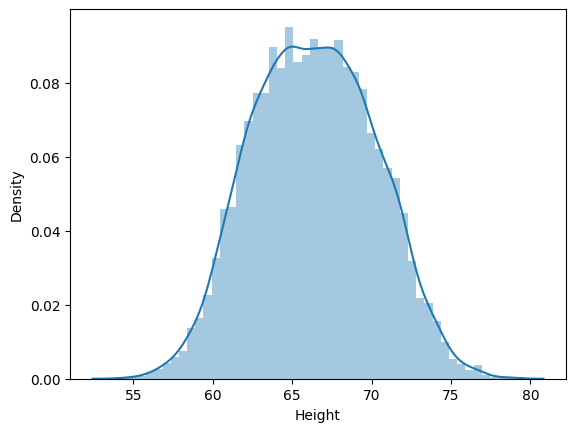

In [8]:
sns.distplot(df['Height'])

<Axes: ylabel='Height'>

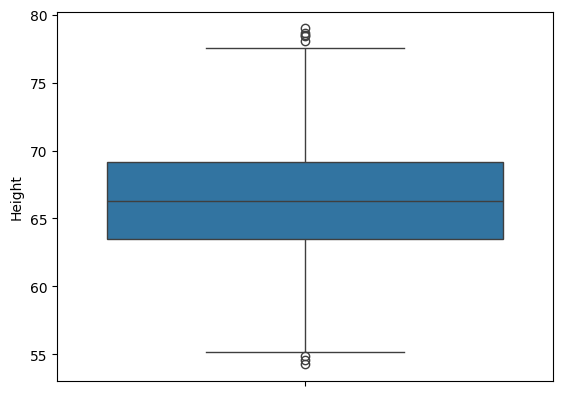

In [9]:
sns.boxplot(df['Height'])

In [10]:
upper_limit = df['Height'].quantile(0.99)
upper_limit

np.float64(74.7857900583366)

In [12]:
lower_limit = df['Height'].quantile(0.01)
lower_limit

np.float64(58.13441158671655)

In [17]:
new_df = df[(df['Height'] <= 74.78) & (df['Height'] >= 58.13)]

In [18]:
new_df['Height'].describe()

count    9799.000000
mean       66.363507
std         3.644267
min        58.134496
25%        63.577147
50%        66.317899
75%        69.119859
max        74.767447
Name: Height, dtype: float64

In [19]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

C:\Users\udaya\AppData\Local\Temp\ipykernel_1972\1622920233.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

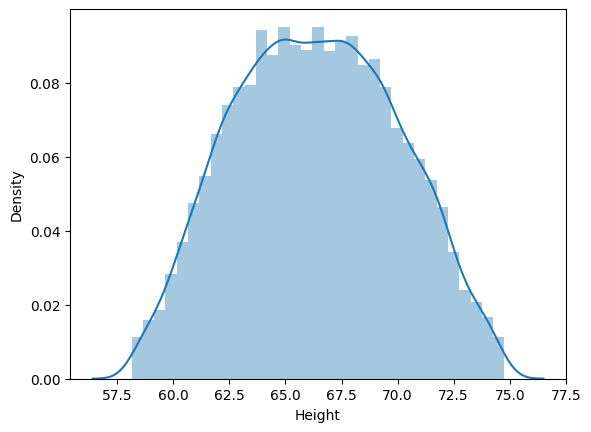

In [20]:
sns.distplot(new_df['Height'])

<Axes: ylabel='Height'>

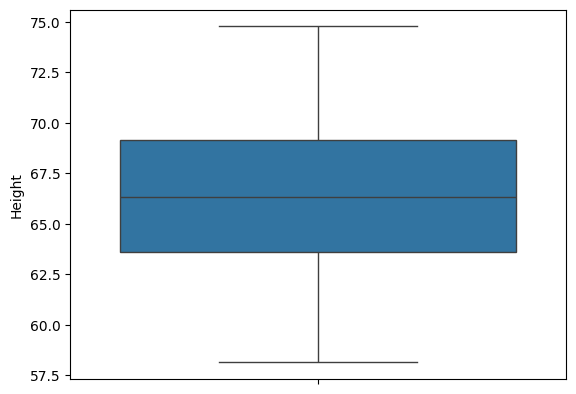

In [21]:
sns.boxplot(new_df['Height'])

## Capping --> Winsorization

In [23]:
df['Height'] = np.where(df['Height'] >= upper_limit,
         upper_limit,
         np.where(df['Height'] <= lower_limit,
         lower_limit,
         df['Height']))

In [25]:
df.shape

(10000, 3)

In [26]:
df['Height'].describe()

count    10000.000000
mean        66.366281
std          3.795717
min         58.134412
25%         63.505620
50%         66.318070
75%         69.174262
max         74.785790
Name: Height, dtype: float64

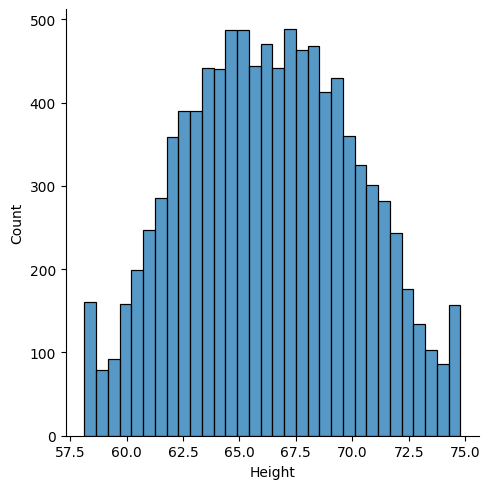

In [27]:
sns.displot(df['Height'])

<Axes: ylabel='Height'>

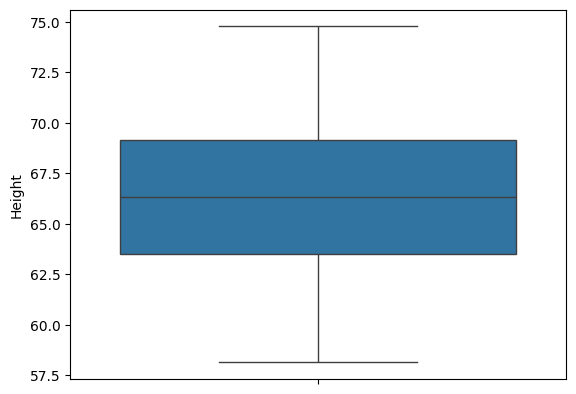

In [28]:
sns.boxplot(df['Height'])